## Regularization - Weights & Biases decay
The goal of this notebook is to test the effect of regularization in terms of weights and biases decay on the performance of SGD optimizer under a linear regression problem.
We will use a synthetic dataset generated using `sklearn.datasets.make_regression` function. The dataset will consist of a specified number of samples and features, and we will introduce some noise to make the problem more realistic.

In [56]:
import numpy as np
from core.dataset.dataset import DataLoader, TensorDataset
from core.tensor import Tensor
from examples.linear_regression.helpers.dataset import split_dataset
from sklearn.datasets import make_regression

SEED = 888
BIAS = 7.2
NOISE = 150
BATCH_SIZE = 16

X, y, true_coefs = make_regression(n_samples=100, n_features=1, n_targets=1, bias=BIAS, noise=NOISE, coef=True, random_state=SEED)

true_coefs = np.array([true_coefs])

X, y = X, y.reshape(-1, 1)

X_tr, X_te = split_dataset(X, axis=0)
y_tr, y_te = split_dataset(y, axis=0)

print(X_tr.shape)

data_tr = TensorDataset(Tensor(X_tr), Tensor(y_tr))
data_te = TensorDataset(Tensor(X_te), Tensor(y_te))

tr_dataloader, te_dataloader = DataLoader(data_tr, BATCH_SIZE), DataLoader(data_te, BATCH_SIZE)


(90, 1)


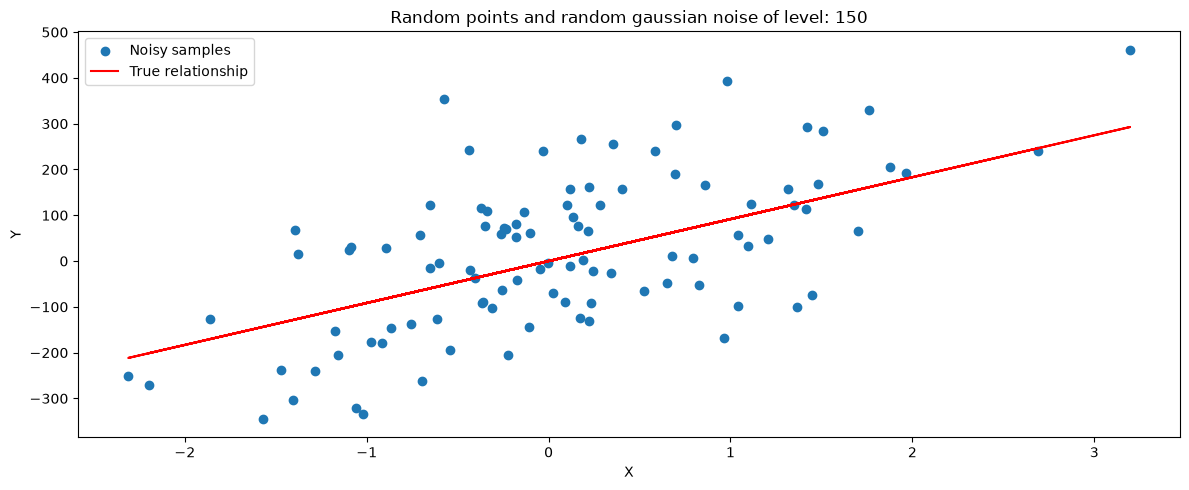

In [57]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax) = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(X, y, label="Noisy samples")
ax.plot(X, X@true_coefs, color="red", label="True relationship")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Random points and random gaussian noise of level: {NOISE}")
ax.legend()

fig.tight_layout()
plt.show()

## Training: decay in isolation

The dataset remain the same across all training runs, the goals is to test the decay coefficients in isolation, with a high variance dataset.

This experiment comprend three different scenarios:
1. No weight decay: 1 dimension of training:
- - several trials on the same dataset

2. Weight decay: 2 dimension of training:
- - several trials for the same decay coefficients with increasing decay coefficients

3. Weight decay + Bias decay: 2 dimension of training:
- - several trials for the same decay coefficients with increasing decay coefficients

## 1. No weight decay

In this scenario we will train the model without any weight decay, and we will evaluate the performance of the model on the test set. We will use a learning rate scheduler and SGD optimizer. 
We will also plot the training and validation loss curves to visualize the performance of the model.

In [58]:
"""Training over the same sample for N_TRIALS, for compute the mean loss."""

from examples.linear_regression.helpers.train import create_trainer, fit_model

EPOCHS = 80
EVAL_STEP = 10
N_TRIALS = 5
MAX_LR, MIN_LR = 1e-2, 1e-4

trainers = [create_trainer(1, 1, MIN_LR, MAX_LR, EPOCHS) for _ in range(N_TRIALS)]

assert len(trainers) == N_TRIALS
for i, trainer in zip(range(N_TRIALS), trainers):
    fit_model(trainer, tr_dataloader, te_dataloader, EPOCHS, EVAL_STEP)


## Loss history and weights interpretation

The loss history are plotted for each trial on the same graph, train and evaluation loss are plotted in different graph, and the weights are also visualized to understand the impact of high variance across spread of weights in several train trials.

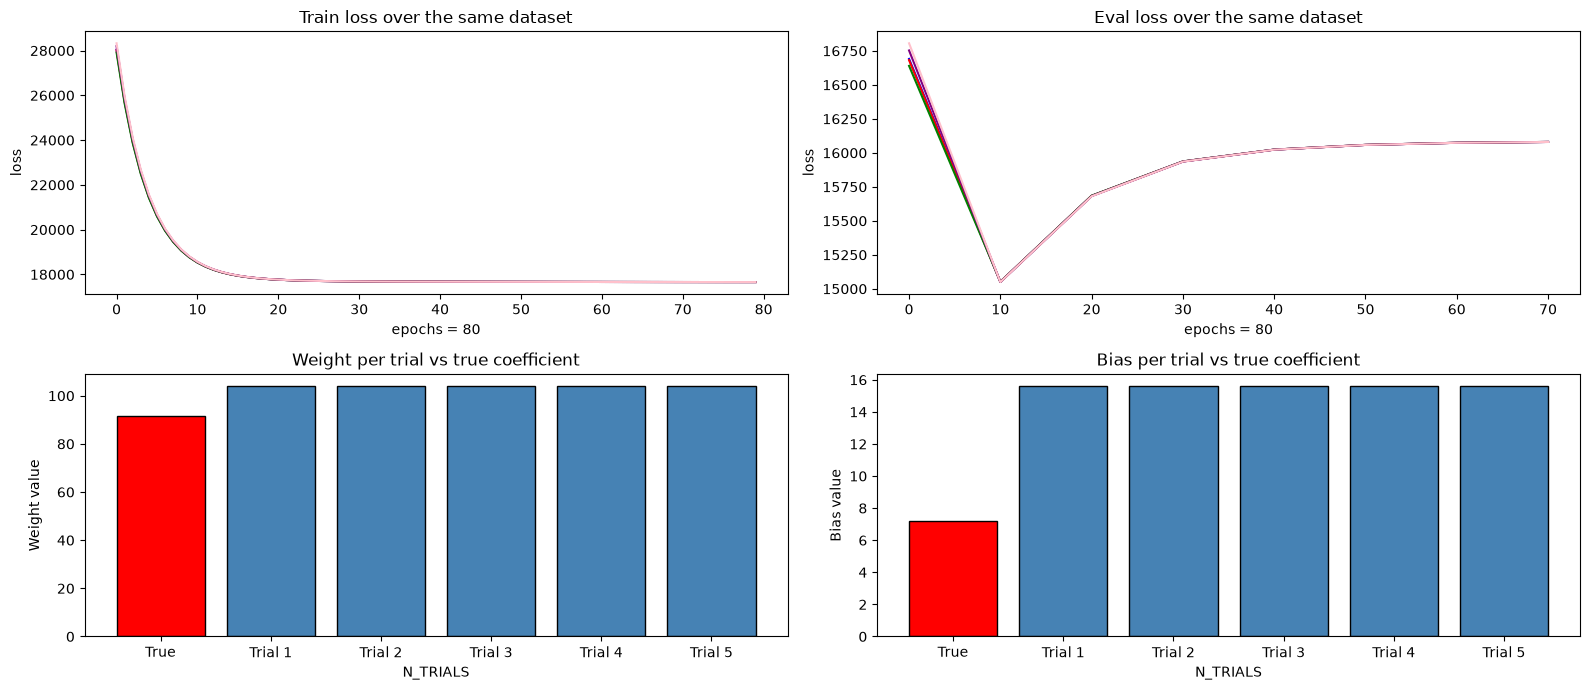

In [59]:
import matplotlib.pyplot as plt
from examples.linear_regression.helpers.train import get_models_params


train_loss_history = [trainer.train_loss for trainer in trainers]
eval_loss_history = [trainer.eval_loss for trainer in trainers]
params_history = get_models_params([trainer.model for trainer in trainers])

weights_history = np.array([p[0].flatten()[0] for p in params_history])
bias_history = np.array([p[1].flatten()[0] for p in params_history])

fig, ((train_ax, eval_ax), (weights_ax, bias_ax)) = plt.subplots(2, 2, figsize=(16, 7))

colors = ['blue', 'red', 'green', 'purple', 'pink']
assert len(colors) == len(train_loss_history)

train_ax.set_title("Train loss over the same dataset")
train_ax.set_ylabel(f"loss")
train_ax.set_xlabel(f"epochs = {EPOCHS}")
for loss, color in zip(train_loss_history, colors):
    train_ax.plot(range(EPOCHS), loss, color=color)

eval_ax.set_title("Eval loss over the same dataset")
eval_ax.set_ylabel(f"loss")
eval_ax.set_xlabel(f"epochs = {EPOCHS}")
for loss, color in zip(eval_loss_history, colors):
    eval_ax.plot(range(0, EPOCHS, EVAL_STEP), loss, color=color)

trial_ticks = range(N_TRIALS + 1)
trial_labels = ["True"] + [f"Trial {i + 1}" for i in range(N_TRIALS)]
bar_colors = ["red"] + ["steelblue"] * N_TRIALS

weights_ax.bar(trial_ticks, [true_coefs[0], *weights_history], color=bar_colors, edgecolor="black")
weights_ax.set_xticks(trial_ticks, trial_labels)
weights_ax.set_title("Weight per trial vs true coefficient")
weights_ax.set_xlabel("N_TRIALS")
weights_ax.set_ylabel("Weight value")

bias_ax.bar(trial_ticks, [BIAS, *bias_history], color=bar_colors, edgecolor="black")
bias_ax.set_xticks(trial_ticks, trial_labels)
bias_ax.set_title("Bias per trial vs true coefficient")
bias_ax.set_xlabel("N_TRIALS")
bias_ax.set_ylabel("Bias value")

fig.tight_layout()
plt.show()
